In [1]:
from dotenv import load_dotenv
from pathlib import Path
import sys
import os

# Walk up until we find the project root (folder with the .env)
current_path = Path().resolve()
for parent in [current_path] + list(current_path.parents):
    if (parent / ".env").exists():
        load_dotenv(parent / ".env")
        project_root = os.getenv("PROJECT_ROOT")
        print(project_root)
        sys.path.append(project_root)     
        break


%load_ext autoreload
%autoreload 2

/Users/emmanuel/Documents/belugas/beluga-call-pipeline


In [8]:
import pandas as pd
import glob
import os

# Path to the snippets directory
snippets_dir = "./snippets"

# Get all folders in the snippets directory
snippet_folders = [f for f in os.listdir(snippets_dir) 
                   if os.path.isdir(os.path.join(snippets_dir, f))]

# Read all files from each folder's manual_verification directory
dfs = []
for folder in snippet_folders:
    manual_verification_dir = os.path.join(snippets_dir, folder, "manual_verification")
    
    # Check if manual_verification directory exists
    if not os.path.exists(manual_verification_dir):
        print(f"No manual_verification folder found in {folder}")
        continue
    
    # Get all files in the manual_verification directory
    manual_files = glob.glob(os.path.join(manual_verification_dir, "*"))
    
    # Read each file and add folder name as a column
    for file in manual_files:
        try:
            df = pd.read_csv(file, sep='\t', engine='python')
            df['site'] = folder  # Add folder name as a column
            dfs.append(df)
            print(f"Read {os.path.basename(file)} from {folder}")
        except Exception as e:
            print(f"Could not read {file}: {e}")

# Concatenate all DataFrames into one
if dfs:
    all_manual_df = pd.concat(dfs, ignore_index=True)
    print(f"\nTotal rows: {len(all_manual_df)}")
    print(f"Datasets: {all_manual_df['site'].unique()}")
else:
    print("No data files found")
    all_manual_df = pd.DataFrame()


Read 201359382.170724140912.snippet.selections.txt from BSM_2017
Read 201359382.170724133858.snippet.selections.txt from BSM_2017
Read 5725.200726191905.snippet.selections_JAA.txt from KAM_2020
Read 5725.200726195504.snippet.selections_JAA.txt from KAM_2020
Read 5725.200726190001.snippet.selections_JAA.txt from KAM_2020
Read 201359382.210714080018.snippet.selections_MA.txt from CAC_2021
Read 201359382.210714083053.snippet.selections_MA.txt from CAC_2021

Total rows: 3601
Datasets: ['BSM_2017' 'KAM_2020' 'CAC_2021']


In [9]:
all_manual_df

,Selection,View,Channel,Begin Time (s),End Time (s),Low Freq (Hz),High Freq (Hz),ECHO,HFPC,BBPC,Whistle,GROUNDTRUTH,Notes,original_filename,snippet_filename,snippet_start_time,snippet_start_s,snippet_end_s,context,site
0,2347,Spectrogram 1,1,0.0,1.0,0.0,96000.0,True,False,False,False,e,NaN,201359382.170724133002.wav,201359382.170724140912.snippet.wav,2017-07-24 14:09:12,2350,2950,ambient,BSM_2017
1,2348,Spectrogram 1,1,1.0,2.0,0.0,96000.0,True,False,False,True,a,NaN,201359382.170724133002.wav,201359382.170724140912.snippet.wav,2017-07-24 14:09:12,2350,2950,ambient,BSM_2017
2,2349,Spectrogram 1,1,2.0,3.0,0.0,96000.0,True,False,False,False,e,NaN,201359382.170724133002.wav,201359382.170724140912.snippet.wav,2017-07-24 14:09:12,2350,2950,ambient,BSM_2017
3,2350,Spectrogram 1,1,3.0,4.0,0.0,96000.0,True,False,False,False,e,NaN,201359382.170724133002.wav,201359382.170724140912.snippet.wav,2017-07-24 14:09:12,2350,2950,ambient,BSM_2017
4,2351,Spectrogram 1,1,4.0,5.0,0.0,96000.0,True,False,False,False,e,NaN,201359382.170724133002.wav,201359382.170724140912.snippet.wav,2017-07-24 14:09:12,2350,2950,ambient,BSM_2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3596,2447,Spectrogram 1,1,595.0,596.0,0.0,96000.0,True,False,False,True,e,NaN,201359382.210714075958.wav,201359382.210714083053.snippet.wav,2021-07-14 08:30:53,1855,2455,boat_passage,CAC_2021
3597,2448,Spectrogram 1,1,596.0,597.0,0.0,96000.0,False,False,False,False,e,NaN,201359382.210714075958.wav,201359382.210714083053.snippet.wav,2021-07-14 08:30:53,1855,2455,boat_passage,CAC_2021
3598,2449,Spectrogram 1,1,597.0,598.0,0.0,96000.0,False,False,False,False,a,NaN,201359382.210714075958.wav,201359382.210714083053.snippet.wav,2021-07-14 08:30:53,1855,2455,boat_passage,CAC_2021
3599,2450,Spectrogram 1,1,598.0,599.0,0.0,96000.0,True,False,False,False,e,NaN,201359382.210714075958.wav,201359382.210714083053.snippet.wav,2021-07-14 08:30:53,1855,2455,boat_passage,CAC_2021


In [10]:
all_manual_df["context"]

0            ambient
1            ambient
2            ambient
3            ambient
4            ambient
            ...     
3596    boat_passage
3597    boat_passage
3598    boat_passage
3599    boat_passage
3600    boat_passage
Name: context, Length: 3601, dtype: object

In [11]:
def set_verif_flags(gt):
    if pd.isna(gt):
        return pd.Series([False, False, False, False])
    gt_str = str(gt)
    if 'a' in gt_str:
        return pd.Series([False, False, False, False])
    return pd.Series([
        'e' in gt_str,  # ECHO_verif
        'b' in gt_str,  # BBPC_verif
        'h' in gt_str,  # HFPC_verif
        'w' in gt_str   # Whislte_verif
    ])

all_manual_df[["ECHO_verif", "BBPC_verif", "HFPC_verif", "Whistle_verif"]] = all_manual_df["GROUNDTRUTH"].apply(set_verif_flags)

In [23]:
all_manual_df["CALL"] = all_manual_df[["ECHO", "BBPC", "HFPC", "Whistle"]].any(axis=1)
all_manual_df["CALL_verif"] = all_manual_df[["ECHO_verif", "BBPC_verif", "HFPC_verif", "Whistle_verif"]].any(axis=1)

In [25]:
print(all_manual_df["CALL_verif"].value_counts())
print(all_manual_df["CALL"].value_counts())

CALL_verif
True     3102
False     499
Name: count, dtype: int64
CALL
True     3013
False     588
Name: count, dtype: int64


In [33]:
print(all_manual_df["ECHO_verif"].value_counts())
print(all_manual_df["BBPC_verif"].value_counts())
print(all_manual_df["HFPC_verif"].value_counts())
print(all_manual_df["Whistle_verif"].value_counts())

ECHO_verif
True     2921
False     680
Name: count, dtype: int64
BBPC_verif
False    3393
True      208
Name: count, dtype: int64
HFPC_verif
False    3392
True      209
Name: count, dtype: int64
Whistle_verif
False    2589
True     1012
Name: count, dtype: int64


# New version

In [29]:
from sklearn.metrics import multilabel_confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================================================================
# Configuration
# =============================================================================
call_types = ["ECHO", "BBPC", "HFPC", "Whistle"]
contexts = ["boat_passage", "ambient"]

# =============================================================================
# Core Metrics Functions
# =============================================================================
def get_multilabel_metrics(df, call_types, subset_name="Overall"):
    """
    Get multilabel metrics and confusion matrices for a dataframe subset.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing predictions and ground truth
    call_types : list
        List of call type names
    subset_name : str
        Name for this subset (e.g., "Overall", "KAM_2020", "boat_passage")
        
    Returns:
    --------
    dict
        Dictionary containing metrics, confusion matrices, and metadata
    """
    if len(df) == 0:
        return None
        
    y_true = df[[f"{c}_verif" for c in call_types]].astype(int).values
    y_pred = df[call_types].astype(int).values
    
    # Get classification report
    report = classification_report(
        y_true, 
        y_pred, 
        target_names=call_types, 
        output_dict=True, 
        zero_division=0
    )
    
    # Get confusion matrices
    mcm = multilabel_confusion_matrix(y_true, y_pred)
    
    return {
        'report': report,
        'mcm': mcm,
        'y_true': y_true,
        'y_pred': y_pred,
        'name': subset_name,
        'n_samples': len(df)
    }


def compute_metrics_by_grouping(df, call_types, group_by=None):
    """
    Compute metrics for overall data and by grouping variable.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing predictions and ground truth
    call_types : list
        List of call type names
    group_by : str or None
        Column name to group by (e.g., 'context', 'site', or None for overall only)
        
    Returns:
    --------
    tuple
        (metrics_overall, metrics_by_group) where metrics_by_group is a dict
    """
    # Overall metrics
    metrics_overall = get_multilabel_metrics(df, call_types, "Overall")
    
    # Group-specific metrics
    metrics_by_group = {}
    if group_by and group_by in df.columns:
        unique_groups = df[group_by].unique()
        for group in unique_groups:
            df_group = df[df[group_by] == group]
            if len(df_group) > 0:
                metrics_by_group[group] = get_multilabel_metrics(df_group, call_types, str(group))
    
    return metrics_overall, metrics_by_group


def create_summary_dataframe(metrics_overall, metrics_by_group, call_types, group_name="Group"):
    """
    Create a summary dataframe from computed metrics.
    
    Parameters:
    -----------
    metrics_overall : dict
        Overall metrics dictionary
    metrics_by_group : dict
        Dictionary of metrics by group
    call_types : list
        List of call type names
    group_name : str
        Name for the grouping column (e.g., "Context", "Site")
        
    Returns:
    --------
    pd.DataFrame
        Summary dataframe with metrics for all call types and groups
    """
    summary_data = []
    
    for call in call_types:
        # Overall
        if metrics_overall:
            summary_data.append({
                'Call Type': call,
                group_name: 'Overall',
                'Precision': metrics_overall['report'][call]['precision'],
                'Recall': metrics_overall['report'][call]['recall'],
                'F1-Score': metrics_overall['report'][call]['f1-score'],
                'Support': int(metrics_overall['report'][call]['support'])
            })
        
        # By group
        for group_key, metrics in metrics_by_group.items():
            if metrics:
                summary_data.append({
                    'Call Type': call,
                    group_name: group_key,
                    'Precision': metrics['report'][call]['precision'],
                    'Recall': metrics['report'][call]['recall'],
                    'F1-Score': metrics['report'][call]['f1-score'],
                    'Support': int(metrics['report'][call]['support'])
                })
    
    return pd.DataFrame(summary_data)


def create_average_metrics_dataframe(metrics_overall, metrics_by_group, group_name="Group"):
    """
    Create dataframe with averaged metrics across all call types.
    
    Parameters:
    -----------
    metrics_overall : dict
        Overall metrics dictionary
    metrics_by_group : dict
        Dictionary of metrics by group
    group_name : str
        Name for the grouping column
        
    Returns:
    --------
    pd.DataFrame
        Dataframe with macro/micro/samples averages
    """
    avg_metrics = []
    
    # Overall
    if metrics_overall:
        report = metrics_overall['report']
        avg_metrics.append({
            group_name: 'Overall',
            'Macro Avg Precision': report['macro avg']['precision'],
            'Macro Avg Recall': report['macro avg']['recall'],
            'Macro Avg F1': report['macro avg']['f1-score'],
            'Micro Avg F1': report['micro avg']['f1-score'],
            'Samples Avg F1': report['samples avg']['f1-score'],
            'n_samples': metrics_overall['n_samples']
        })
    
    # By group
    for group_key, metrics in metrics_by_group.items():
        if metrics:
            report = metrics['report']
            avg_metrics.append({
                group_name: group_key,
                'Macro Avg Precision': report['macro avg']['precision'],
                'Macro Avg Recall': report['macro avg']['recall'],
                'Macro Avg F1': report['macro avg']['f1-score'],
                'Micro Avg F1': report['micro avg']['f1-score'],
                'Samples Avg F1': report['samples avg']['f1-score'],
                'n_samples': metrics['n_samples']
            })
    
    return pd.DataFrame(avg_metrics)


def plot_metrics_comparison(summary_df, group_name="Group", exclude_overall=True, figsize=(14, 10)):
    """
    Create bar plots comparing metrics across call types and groups.
    
    Parameters:
    -----------
    summary_df : pd.DataFrame
        Summary dataframe with metrics
    group_name : str
        Name of the grouping column
    exclude_overall : bool
        Whether to exclude 'Overall' from visualization
    figsize : tuple
        Figure size
        
    Returns:
    --------
    matplotlib.figure.Figure
        The created figure
    """
    # Filter data
    plot_df = summary_df.copy()
    if exclude_overall:
        plot_df = plot_df[plot_df[group_name] != 'Overall']
    
    if len(plot_df) == 0:
        print("No data to plot after filtering")
        return None
    
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    metrics_to_plot = ['Precision', 'Recall', 'F1-Score', 'Support']
    
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx // 2, idx % 2]
        
        # Pivot data for plotting
        pivot_data = plot_df.pivot(index='Call Type', columns=group_name, values=metric)
        
        pivot_data.plot(kind='bar', ax=ax, rot=0)
        ax.set_title(f'{metric} by Call Type and {group_name}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Call Type')
        ax.set_ylabel(metric)
        ax.legend(title=group_name, loc='best')
        ax.grid(axis='y', alpha=0.3)
        
        # Set y-limit only for percentage metrics
        if metric in ['Precision', 'Recall', 'F1-Score']:
            ax.set_ylim([0, 1.0])
    
    plt.tight_layout()
    return fig


def print_classification_report(metrics_overall, call_types):
    """Print formatted classification report."""
    if metrics_overall:
        print(f"\n{'='*80}")
        print("OVERALL CLASSIFICATION REPORT")
        print(f"{'='*80}\n")
        print(classification_report(
            metrics_overall['y_true'], 
            metrics_overall['y_pred'], 
            target_names=call_types, 
            zero_division=0
        ))


def print_summary_table(summary_df, group_name="Group"):
    """Print formatted summary table."""
    print(f"\n\n{'='*80}")
    print(f"SUMMARY TABLE: All Call Types by {group_name}")
    print(f"{'='*80}\n")
    print(summary_df.to_string(index=False))


def print_average_metrics(avg_df, group_name="Group"):
    """Print formatted average metrics table."""
    print(f"\n\n{'='*80}")
    print(f"AVERAGE METRICS ACROSS ALL CALL TYPES BY {group_name}")
    print(f"{'='*80}\n")
    print(avg_df.to_string(index=False))

ANALYSIS BY CONTEXT

OVERALL CLASSIFICATION REPORT

              precision    recall  f1-score   support

        ECHO       0.98      0.94      0.96      2921
        BBPC       0.59      0.55      0.57       208
        HFPC       0.62      0.87      0.72       209
     Whistle       0.81      0.83      0.82      1012

   micro avg       0.90      0.89      0.89      4350
   macro avg       0.75      0.79      0.77      4350
weighted avg       0.90      0.89      0.90      4350
 samples avg       0.77      0.78      0.76      4350



SUMMARY TABLE: All Call Types by Context

Call Type      Context  Precision   Recall  F1-Score  Support
     ECHO      Overall   0.979964 0.937693  0.958362     2921
     ECHO      ambient   0.982349 0.945134  0.963382     1531
     ECHO boat_passage   0.977307 0.929496  0.952802     1390
     BBPC      Overall   0.593750 0.548077  0.570000      208
     BBPC      ambient   0.670103 0.496183  0.570175      131
     BBPC boat_passage   0.515789 0.636364 

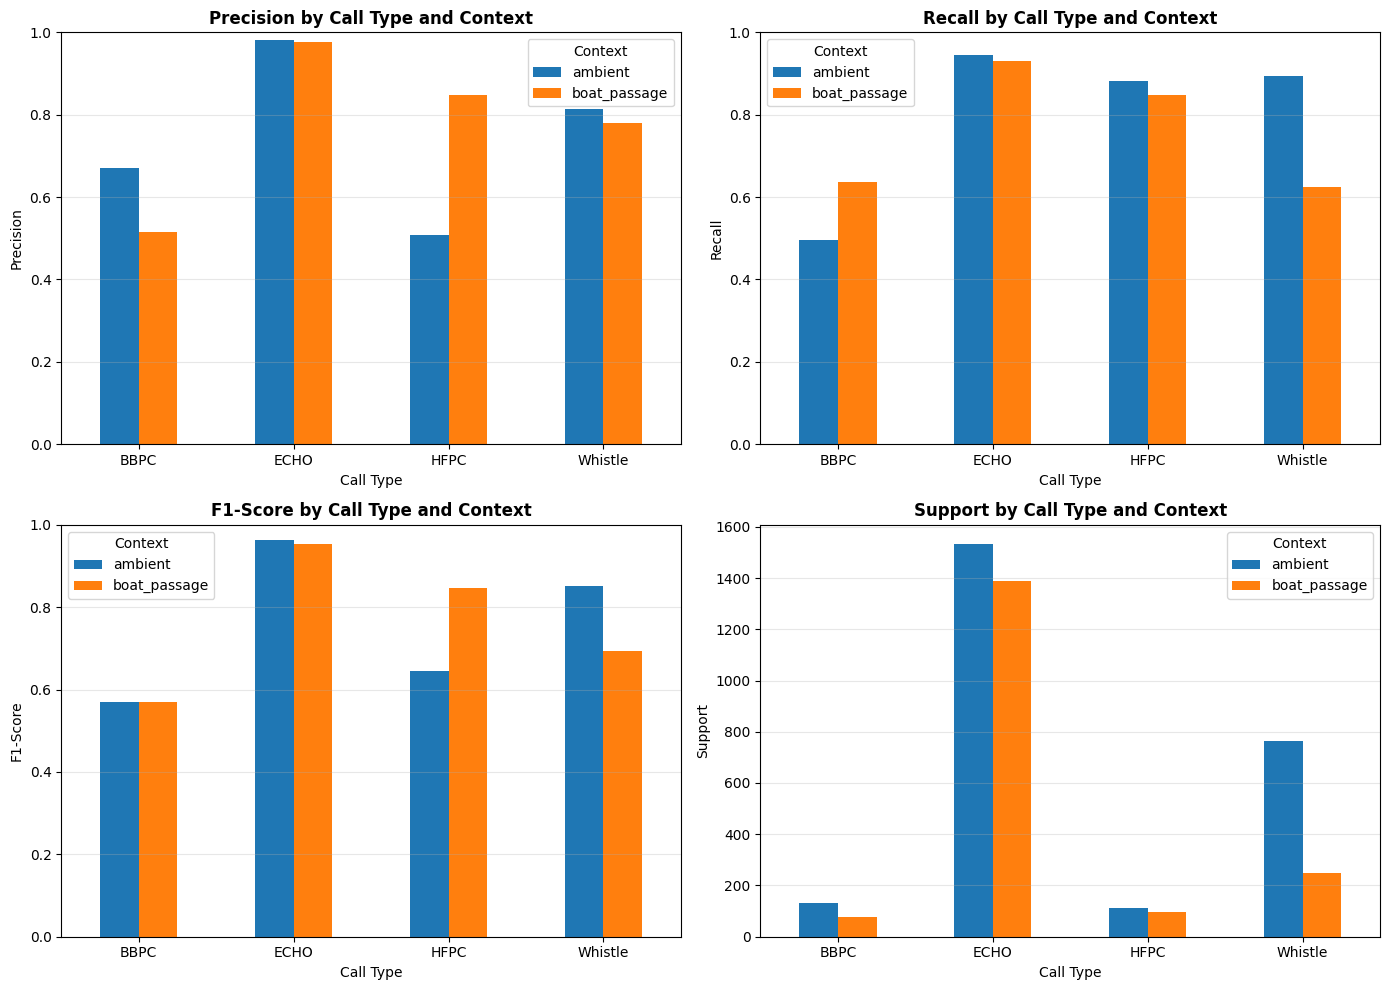

In [30]:
# =============================================================================
# ANALYSIS BY CONTEXT
# =============================================================================
print("="*80)
print("ANALYSIS BY CONTEXT")
print("="*80)

# Compute metrics
metrics_overall, metrics_by_context = compute_metrics_by_grouping(
    all_manual_df, call_types, group_by='context'
)

# Print reports
print_classification_report(metrics_overall, call_types)

# Create summary dataframes
summary_by_context = create_summary_dataframe(
    metrics_overall, metrics_by_context, call_types, group_name="Context"
)
print_summary_table(summary_by_context, "Context")

avg_by_context = create_average_metrics_dataframe(
    metrics_overall, metrics_by_context, group_name="Context"
)
print_average_metrics(avg_by_context, "Context")

# Plot
fig_context = plot_metrics_comparison(
    summary_by_context, group_name="Context", exclude_overall=True
)
plt.show()



ANALYSIS BY SITE


SUMMARY TABLE: All Call Types by Site

Call Type     Site  Precision   Recall  F1-Score  Support
     ECHO BSM_2017   0.934911 0.869326  0.900927      727
     ECHO KAM_2020   0.996435 0.977273  0.986761     1144
     ECHO CAC_2021   0.991976 0.941905  0.966292     1050
     BBPC BSM_2017   0.486486 0.450000  0.467532       40
     BBPC KAM_2020   0.484848 0.615385  0.542373       52
     BBPC CAC_2021   0.719101 0.551724  0.624390      116
     HFPC BSM_2017   0.740157 0.886792  0.806867      106
     HFPC KAM_2020   0.636364 0.823529  0.717949       34
     HFPC CAC_2021   0.491667 0.855072  0.624339       69
  Whistle BSM_2017   0.419580 0.923077  0.576923       65
  Whistle KAM_2020   0.713262 0.861472  0.780392      231
  Whistle CAC_2021   0.941368 0.807263  0.869173      716


AVERAGE METRICS ACROSS ALL CALL TYPES BY Site

    Site  Macro Avg Precision  Macro Avg Recall  Macro Avg F1  Micro Avg F1  Samples Avg F1  n_samples
BSM_2017             0.645284     

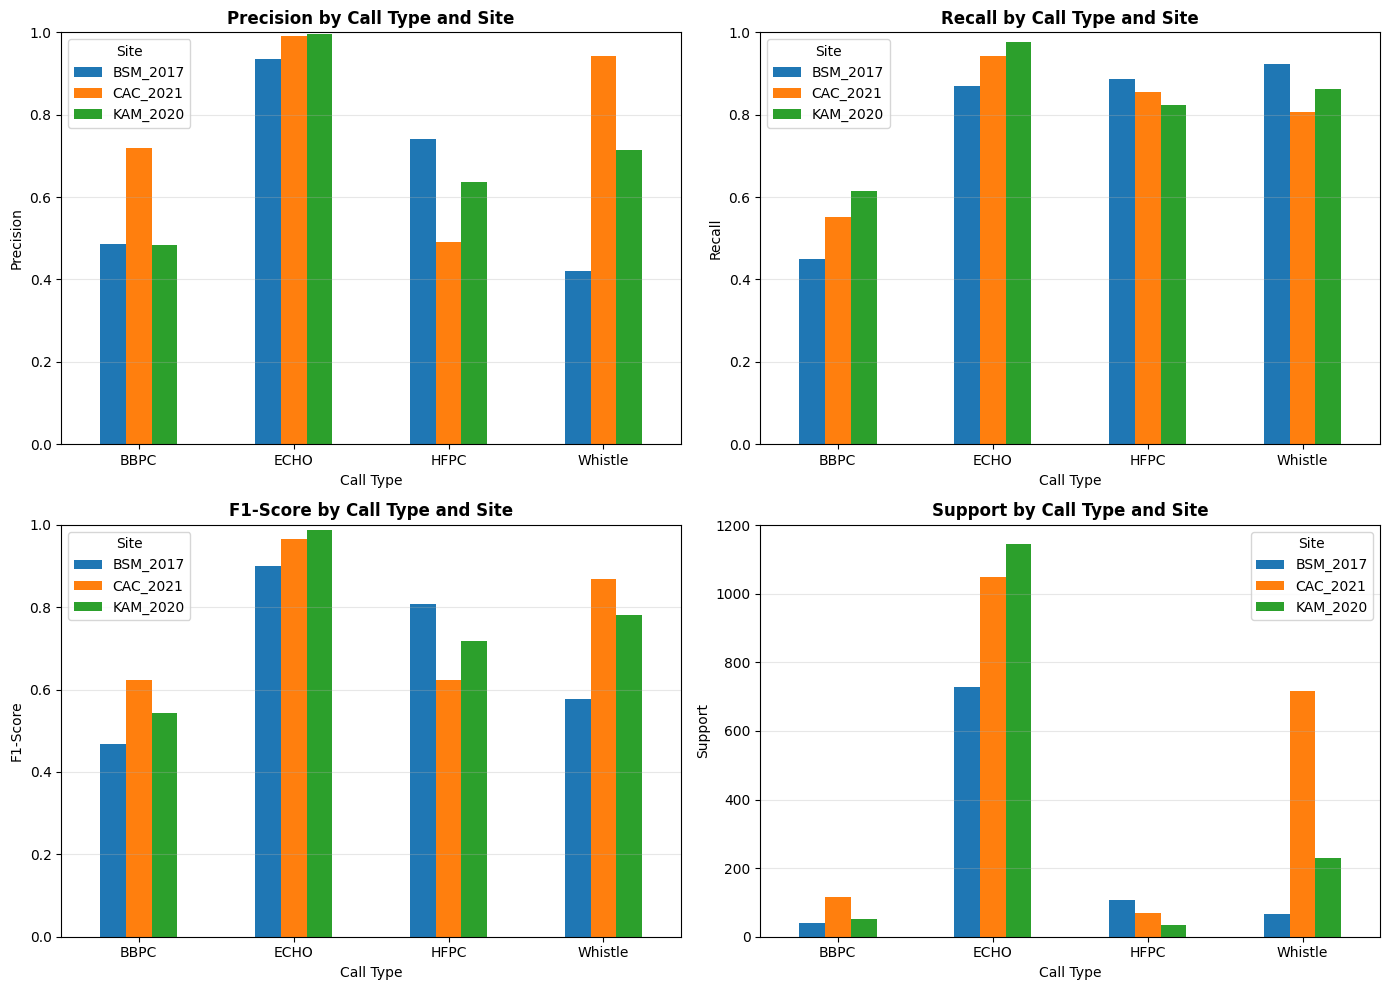

In [20]:
# =============================================================================
# ANALYSIS BY SITE
# =============================================================================
print("\n\n" + "="*80)
print("ANALYSIS BY SITE")
print("="*80)

# Compute metrics
_, metrics_by_site = compute_metrics_by_grouping(
    all_manual_df, call_types, group_by='site'
)

# Create summary dataframes (no overall for site comparison)
summary_by_site = create_summary_dataframe(
    None, metrics_by_site, call_types, group_name="Site"
)
print_summary_table(summary_by_site, "Site")

avg_by_site = create_average_metrics_dataframe(
    None, metrics_by_site, group_name="Site"
)
print_average_metrics(avg_by_site, "Site")

# Plot
fig_site = plot_metrics_comparison(
    summary_by_site, group_name="Site", exclude_overall=False
)
plt.show()



ANALYSIS BY SITE AND CONTEXT


SUMMARY TABLE: All Call Types by Site-Context

Call Type            Site-Context  Precision   Recall  F1-Score  Support
     ECHO      BSM_2017 - ambient   0.934524 0.846361  0.888260      371
     ECHO BSM_2017 - boat_passage   0.935294 0.893258  0.913793      356
     ECHO KAM_2020 - boat_passage   0.992352 0.954044  0.972821      544
     ECHO      KAM_2020 - ambient   1.000000 0.998333  0.999166      600
     ECHO      CAC_2021 - ambient   0.992565 0.953571  0.972678      560
     ECHO CAC_2021 - boat_passage   0.991285 0.928571  0.958904      490
     BBPC      BSM_2017 - ambient   0.535714 0.416667  0.468750       36
     BBPC BSM_2017 - boat_passage   0.333333 0.750000  0.461538        4
     BBPC KAM_2020 - boat_passage   0.428571 0.648649  0.516129       37
     BBPC      KAM_2020 - ambient   0.800000 0.533333  0.640000       15
     BBPC      CAC_2021 - ambient   0.711864 0.525000  0.604317       80
     BBPC CAC_2021 - boat_passage   0.733333

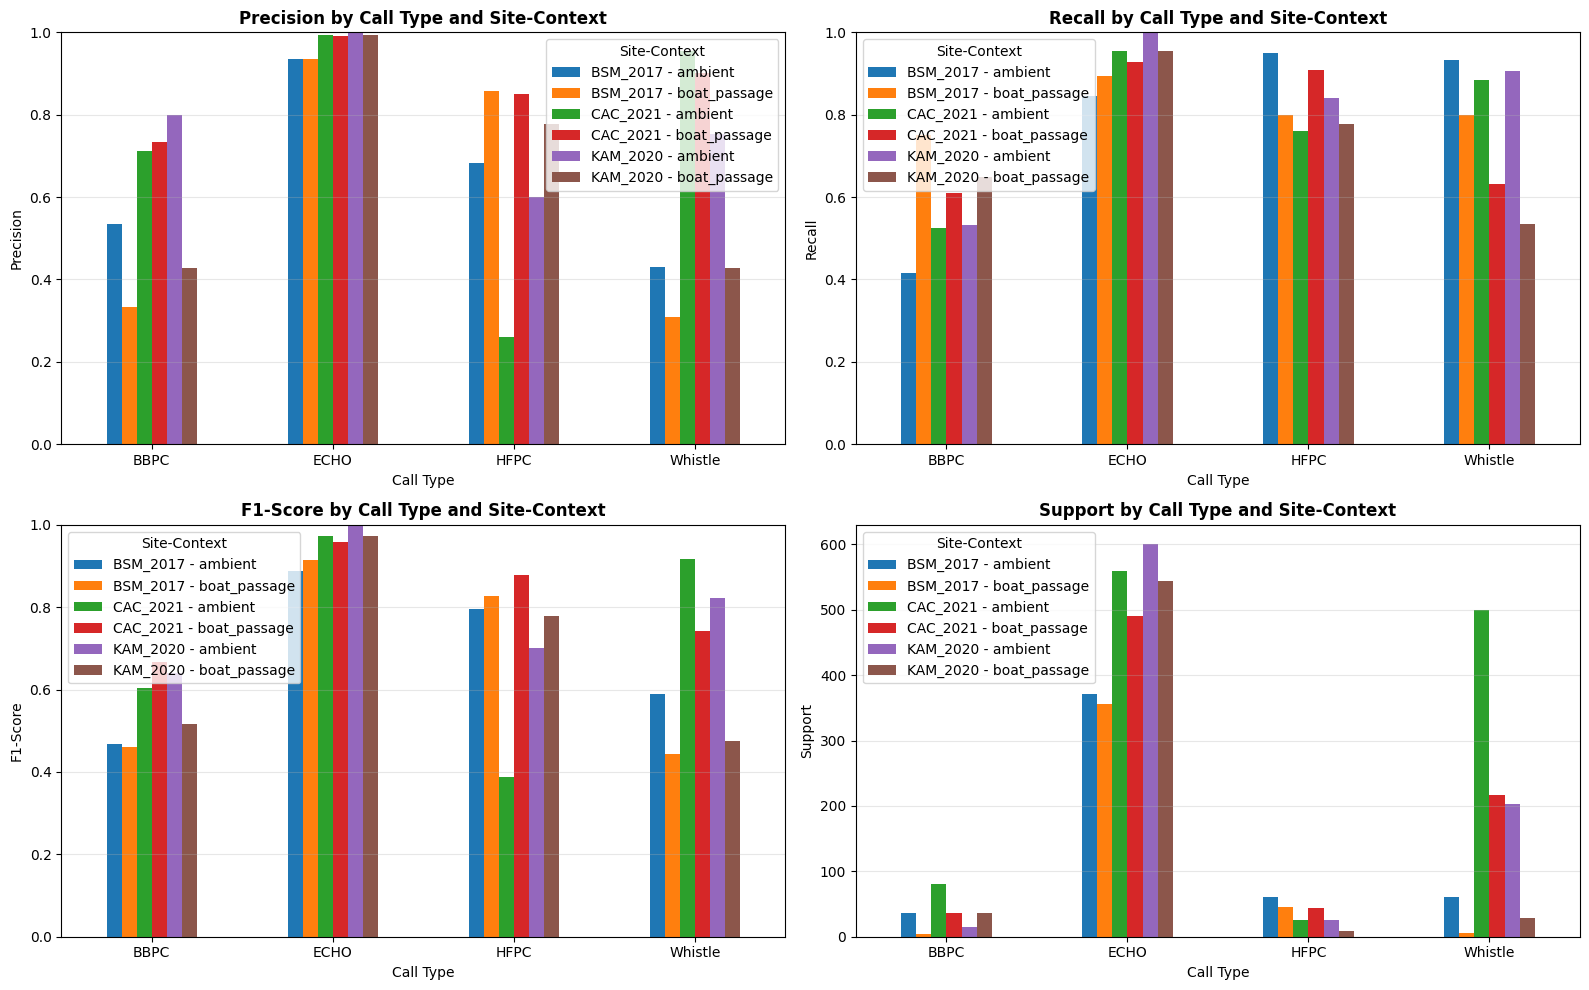

In [21]:
# =============================================================================
# ANALYSIS BY SITE AND CONTEXT (COMBINED)
# =============================================================================
print("\n\n" + "="*80)
print("ANALYSIS BY SITE AND CONTEXT")
print("="*80)

# Create combined site_context column
all_manual_df['site_context'] = all_manual_df['site'] + ' - ' + all_manual_df['context']

# Compute metrics
_, metrics_by_site_context = compute_metrics_by_grouping(
    all_manual_df, call_types, group_by='site_context'
)

# Create summary dataframes
summary_by_site_context = create_summary_dataframe(
    None, metrics_by_site_context, call_types, group_name="Site-Context"
)
print_summary_table(summary_by_site_context, "Site-Context")

avg_by_site_context = create_average_metrics_dataframe(
    None, metrics_by_site_context, group_name="Site-Context"
)
print_average_metrics(avg_by_site_context, "Site-Context")

# Plot (this might be crowded with many combinations)
fig_site_context = plot_metrics_comparison(
    summary_by_site_context, group_name="Site-Context", 
    exclude_overall=False, figsize=(16, 10)
)
plt.show()

## Sanity check of past results

training_pre

In [45]:
training_results_df = pd.read_csv("/Users/emmanuel/Documents/belugas/beluga-call-pipeline/training/results/model_optimization/mobile_net_hp_200_resize_layers_10/test_predictions.csv")
# training_results_df = training_results_df[training_results_df["Fold"] == 1]

In [46]:
training_results_df

call_types = ["ECHO", "CC", "HFPC", "Whistle"]

# Prepare multilabel arrays for training_results_df, using ECHO_true, ECHO_pred, etc. columns (as floats 0.0/1.0)
y_true = training_results_df[[f"{c}_true" for c in call_types]].astype(int).values
y_pred = training_results_df[[f"{c}_pred" for c in call_types]].astype(int).values

# Get all confusion matrices at once
mcm = multilabel_confusion_matrix(y_true, y_pred)

print(classification_report(
    y_true, 
    y_pred, 
    target_names=call_types, 
    zero_division=0
))
# Get full report as dictionary
report = classification_report(
    y_true, 
    y_pred, 
    target_names=call_types, 
    output_dict=True, 
    zero_division=0
)
# Per-class confusion matrix
for i, call in enumerate(call_types):
    print(f"\n{call} confusion matrix:")
    print(mcm[i])  # [[TN, FP], [FN, TP]]

              precision    recall  f1-score   support

        ECHO       0.94      0.93      0.93      2725
          CC       0.94      0.91      0.93      1148
        HFPC       0.94      0.89      0.91      1212
     Whistle       0.96      0.94      0.95      2998

   micro avg       0.95      0.92      0.93      8083
   macro avg       0.94      0.92      0.93      8083
weighted avg       0.95      0.92      0.93      8083
 samples avg       0.73      0.72      0.72      8083


ECHO confusion matrix:
[[2360  166]
 [ 201 2524]]

CC confusion matrix:
[[4036   67]
 [ 102 1046]]

HFPC confusion matrix:
[[3967   72]
 [ 137 1075]]

Whistle confusion matrix:
[[2128  125]
 [ 173 2825]]
